# Training a 1D-CNN model in PyTorch to classify brain activities from EEG.


### Setp


In [17]:
import re
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn import preprocessing, model_selection
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# print("Python executable:", __import__("sys").executable)
print("Torch version:", torch.__version__)
print("Device:", DEVICE)


Torch version: 2.11.0+cu126
Device: cuda


### Constants and configs


In [2]:
RAW_PATH = Path("EEG/eeg-data.csv")
LABELS_JSON_PATH = Path("labels.json")
REPORT_DIR = Path("outputs/reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

TEST_SPLIT = 0.3
DEBUG = False
DEBUG_SIZE = 1000
USE_MAJOR_CLASSES = True
SEQ_LEN = 512
BATCH_SIZE = 1024
MAX_EPOCHS = 30
EARLY_STOP_PATIENCE = 5
LR = 1e-3
WEIGHT_DECAY = 1e-3
DROPOUT = 0.25
LABEL_SMOOTHING = 0.08
MAX_GRAD_NORM = 1.0

# --- Experiment controls ---
# 'stratified' reproduces the previous easier setting; 'group' is stricter subject holdout.
SPLIT_STRATEGY = "group"  # options: 'stratified', 'group'
USE_WEIGHTED_SAMPLER = False
USE_CLASS_WEIGHTS = True

# --- K-fold controls ---
KFOLD_N_SPLITS = 5
KFOLD_MAX_EPOCHS = 20
KFOLD_ENABLED = True

print("Raw exists:", RAW_PATH.exists())
print("labels.json exists:", LABELS_JSON_PATH.exists())
print("Report dir:", REPORT_DIR)
print("Split strategy:", SPLIT_STRATEGY)
print("Use weighted sampler:", USE_WEIGHTED_SAMPLER)
print("Use class weights:", USE_CLASS_WEIGHTS)
print("K-fold enabled:", KFOLD_ENABLED)
print("K-fold n_splits:", KFOLD_N_SPLITS)
print("K-fold max epochs:", KFOLD_MAX_EPOCHS)

Raw exists: True
labels.json exists: True
Report dir: outputs\reports
Split strategy: group
Use weighted sampler: False
Use class weights: True
K-fold enabled: True
K-fold n_splits: 5
K-fold max epochs: 20


## Utility functions


In [3]:
def parse_num_list(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text[0] == "[" and text[-1] == "]":
        text = text[1:-1]
    arr = np.fromstring(text, sep=",", dtype=np.float32)
    if arr.size == 0:
        return None
    return arr


def fix_len(arr, n):
    if arr is None:
        return None
    if arr.size == n:
        return arr.astype(np.float32)
    if arr.size > n:
        return arr[:n].astype(np.float32)
    out = np.zeros(n, dtype=np.float32)
    out[: arr.size] = arr
    return out


def power_to_seq(power, n=512):
    if power is None:
        return None
    power = fix_len(power, 8)
    x_old = np.arange(8, dtype=np.float32)
    x_new = np.linspace(0, 7, n, dtype=np.float32)
    return np.interp(x_new, x_old, power).astype(np.float32)


if not LABELS_JSON_PATH.exists():
    raise FileNotFoundError(f"Missing label mapping file: {LABELS_JSON_PATH}")

_RAW_LABEL_MAP = json.loads(LABELS_JSON_PATH.read_text(encoding="utf-8"))


def _resolve_label_once(src: str, label_map: dict, cache: dict) -> str:
    if src in cache:
        return cache[src]

    seen = set()
    cur = src
    while cur in label_map and cur not in seen:
        seen.add(cur)
        cur = label_map[cur]

    cache[src] = cur
    return cur


# Flatten any chained mappings exactly once for O(1) runtime lookup.
_RESOLVED_LABEL_MAP = {}
for _key in _RAW_LABEL_MAP:
    _resolve_label_once(_key, _RAW_LABEL_MAP, _RESOLVED_LABEL_MAP)

# Optional case-insensitive support.
_RESOLVED_LABEL_MAP_LOWER = {k.lower(): v for k, v in _RESOLVED_LABEL_MAP.items()}


def to_major_class(label: str) -> str:
    s = str(label).strip()
    if not s:
        return s

    mapped = _RESOLVED_LABEL_MAP.get(s)
    if mapped is not None:
        return mapped

    mapped = _RESOLVED_LABEL_MAP_LOWER.get(s.lower())
    if mapped is not None:
        return mapped

    # Fast fallback for unseen labels.
    base = re.split(r"[-_]", s)[0]
    base = re.sub(r"\d+$", "", base)
    return base or s

## Lodaing the data


In [4]:
eeg_data = pd.read_csv(RAW_PATH, converters={"eeg_power": parse_num_list, "raw_values": parse_num_list})
eeg_data = eeg_data.loc[eeg_data["signal_quality"]<128]
print("Data shape:", eeg_data.shape)
print("Columns:", eeg_data.columns)

Data shape: (26460, 13)
Columns: Index(['Unnamed: 0', 'id', 'indra_time', 'browser_latency', 'reading_time',
       'attention_esense', 'meditation_esense', 'eeg_power', 'raw_values',
       'signal_quality', 'createdAt', 'updatedAt', 'label'],
      dtype='object')


In [5]:
# Let's drop the unwanted/unnecessary columns:
eeg_data = eeg_data[['id', 'eeg_power', 'raw_values', 'label']]
print("Data shape after dropping unnecessary columns:", eeg_data.shape)

# Classes in the data:
eeg_data['label'].value_counts(dropna=False)

Data shape after dropping unnecessary columns: (26460, 4)


label
unlabeled            16506
relax                  934
music                  932
video-ver2             481
thinkOfItems-ver2      481
                     ...  
colorRound4-3           32
colorRound4-5           32
colorRound4-2           30
colorRound4-1           29
colorRound4-4           29
Name: count, Length: 68, dtype: int64

In [6]:
# we drop the "unlabeled" samples:
eeg_data = eeg_data[eeg_data['label'] != 'unlabeled']
print("Data shape after dropping unlabeled:", eeg_data.shape)

Data shape after dropping unlabeled: (9954, 4)


In [7]:
# collate the minor classes into major ones:
eeg_data['label'] = eeg_data['label'].map(to_major_class)
eeg_data.reset_index(inplace=True)
print(f"Data shape after collating minor classes into major ones: {eeg_data.shape}")
print(f"Unique classes after collating minor classes into major ones: \n\t{len(eeg_data['label'].unique())}")

Data shape after collating minor classes into major ones: (9954, 5)
Unique classes after collating minor classes into major ones: 
	19


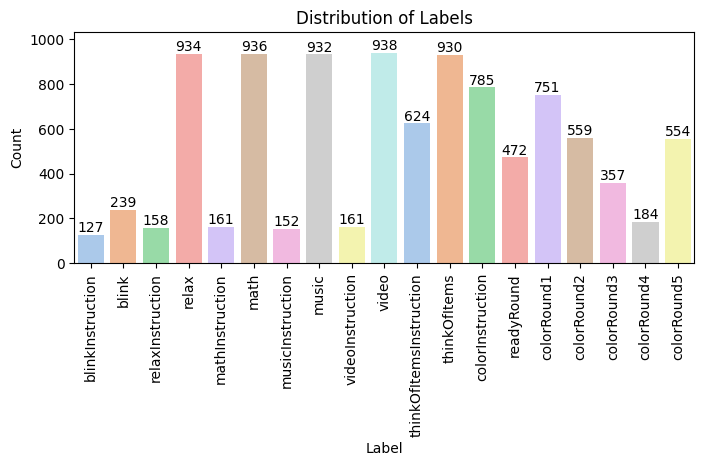

In [8]:
plt.figure(figsize=(8, 3))
sns.countplot(x='label', data=eeg_data, palette='pastel', hue='label')
for label in eeg_data.label.value_counts().keys():
    count = eeg_data[eeg_data.label == label].shape[0]
    plt.text(label, count, str(count), ha='center', va='bottom', rotation=0)
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.ylim(0, max(eeg_data['label'].value_counts()) * 1.1)
plt.show()

## Normalizing the class imbalanceness

### Method 1. Simply assigning the 1-complement proportion of each class (naive method).

### Method 2. Normalizing the class weights from Mehotd 1 with (C - 1), where C is the number of classes.

### Method 3: Normlized inverse of class proportions (reverse distribution sould be observed!).


Mean of complementary: 0.9474 	 STD of complementary: 0.0326
Mean of normalized   : 0.0526 	 STD of normalized   : 0.0018


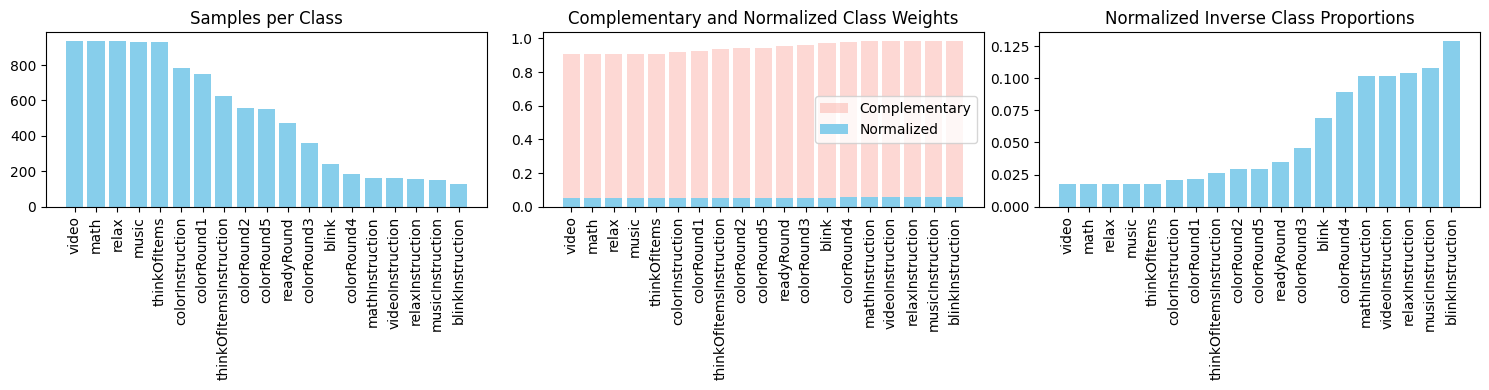

In [9]:
num_classes = len(eeg_data['label'].unique())
# print(f"Number of unique classes: {num_classes}")
sample_per_class = eeg_data['label'].value_counts()
class_proportions = eeg_data['label'].value_counts(normalize=True)

# Method 1: class weight = 1 - class proportion 
complementary_class_weights = (1.0 - class_proportions)

# Method 2: class weight = (1 - class proportion) / (num_classes - 1)
normalized_class_weights = complementary_class_weights / (num_classes - 1)

print(f'Mean of complementary: {complementary_class_weights.mean():.4f} \t STD of complementary: {complementary_class_weights.std():.4f}')
print(f'Mean of normalized   : {normalized_class_weights.mean():.4f} \t STD of normalized   : {normalized_class_weights.std():.4f}')

# Method 3: class weight = 1 / class proportion
normalized_inverse_proportions = 1.0 / (class_proportions + 1e-8)
normalized_inverse_proportions = normalized_inverse_proportions / normalized_inverse_proportions.sum()

# print("Class proportions:\n", class_proportions)
# print("Class weights:\n", normalized_class_weights)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].bar(sample_per_class.index, sample_per_class.values, color='skyblue')
axs[0].set_title('Samples per Class')
axs[0].set_xticks(ticks=range(len(sample_per_class.index)))
axs[0].set_xticklabels(labels=sample_per_class.index, rotation=90)

axs[1].bar(complementary_class_weights.index, complementary_class_weights.values, color='salmon', alpha=0.3, label='Complementary')
axs[1].bar(normalized_class_weights.index, normalized_class_weights.values, color='skyblue', label='Normalized')
axs[1].set_title('Complementary and Normalized Class Weights')
axs[1].set_xticks(ticks=range(len(normalized_class_weights.index)))
axs[1].set_xticklabels(labels=normalized_class_weights.index, rotation=90)
axs[1].legend(loc='right')

axs[2].bar(normalized_inverse_proportions.index, normalized_inverse_proportions.values, color='skyblue')
axs[2].set_title('Normalized Inverse Class Proportions')
axs[2].set_xticks(ticks=range(len(normalized_inverse_proportions.index)))
axs[2].set_xticklabels(labels=normalized_inverse_proportions.index, rotation=90)

plt.tight_layout()
plt.show()

## Normalizing the raw values


Scaler mean: 44.4820, scale: 101.7862
MinMax min: -20.5576, max: 19.6738


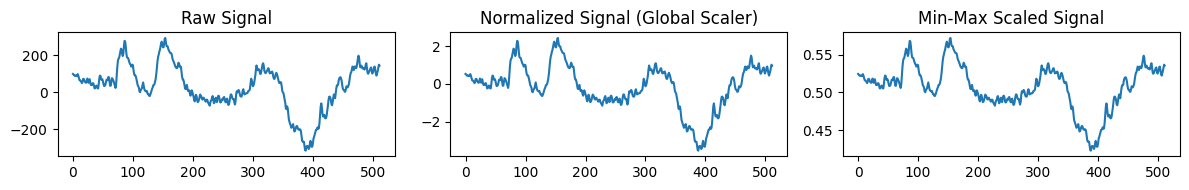

In [10]:
# Fit scaler ONCE on all flattened data, then apply to each sample
all_raw_values = np.concatenate([x for x in eeg_data['raw_values'] if x is not None])
scaler = preprocessing.StandardScaler()
scaler.fit(all_raw_values.reshape(-1, 1))
print(f"Scaler mean: {scaler.mean_[0]:.4f}, scale: {scaler.scale_[0]:.4f}")

# Now transform each sample using the fitted scaler
eeg_data['normalized_raw_values'] = eeg_data['raw_values'].apply(
    lambda x: scaler.transform(x.reshape(-1, 1)).flatten() if x is not None else None
)

# Fit MinMaxScaler ONCE on all flattened and normalized data, then apply to each sample
all_raw_values = np.concatenate([x for x in eeg_data['normalized_raw_values'] if x is not None])
scaler = preprocessing.MinMaxScaler()
scaler.fit(all_raw_values.reshape(-1, 1))
print(f"MinMax min: {scaler.data_min_[0]:.4f}, max: {scaler.data_max_[0]:.4f}")

eeg_data['minmax_raw_values'] = eeg_data['normalized_raw_values'].apply(
    lambda x: scaler.transform(x.reshape(-1, 1)).flatten() if x is not None else None
)

fig, axs = plt.subplots(1, 3, figsize=(12, 2))
axs[0].plot(eeg_data['raw_values'][0], label='Raw Values')
axs[1].plot(eeg_data['normalized_raw_values'][0], label='Normalized Raw Values')
axs[2].plot(eeg_data['minmax_raw_values'][0], label='Min-Max Scaled Raw Values')
axs[0].set_title('Raw Signal')
axs[1].set_title('Normalized Signal (Global Scaler)')
axs[2].set_title('Min-Max Scaled Signal')
plt.tight_layout()
plt.show()

# Dataloaders for train/val/test


In [11]:
debug_size = DEBUG_SIZE if DEBUG else len(eeg_data)
data_for_split = eeg_data.iloc[:debug_size].copy().reset_index(drop=True)

if SPLIT_STRATEGY == 'group' and 'id' in data_for_split.columns:
    gss = model_selection.GroupShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=42)
    train_idx, val_idx = next(gss.split(data_for_split, data_for_split['label'], groups=data_for_split['id']))
    train_data = data_for_split.iloc[train_idx].copy().reset_index(drop=True)
    val_data = data_for_split.iloc[val_idx].copy().reset_index(drop=True)
    print('Split strategy used: GroupShuffleSplit by subject id')
else:
    train_data, val_data = model_selection.train_test_split(
        data_for_split,
        test_size=TEST_SPLIT,
        stratify=data_for_split['label'],
        random_state=42,
    )
    train_data = train_data.reset_index(drop=True)
    val_data = val_data.reset_index(drop=True)
    print('Split strategy used: Stratified random split')

label_encoder = preprocessing.LabelEncoder().fit(train_data['label'])
val_data = val_data[val_data['label'].isin(label_encoder.classes_)].copy().reset_index(drop=True)

def _safe_array(x):
    if x is None:
        return None
    arr = np.asarray(x, dtype=np.float32)
    if arr.size == 0:
        return None
    return arr

def _fit_split_safe_scalers(train_df, val_df):
    train_raw = [_safe_array(x) for x in train_df['raw_values']]
    train_raw = [x for x in train_raw if x is not None]
    if len(train_raw) == 0:
        raise RuntimeError('No valid raw_values found in train split for scaling.')

    train_flat = np.concatenate(train_raw)
    std_scaler = preprocessing.StandardScaler()
    std_scaler.fit(train_flat.reshape(-1, 1))

    def _std_transform(x):
        arr = _safe_array(x)
        if arr is None:
            return None
        return std_scaler.transform(arr.reshape(-1, 1)).flatten().astype(np.float32)

    train_df = train_df.copy()
    val_df = val_df.copy()
    train_df['normalized_raw_values'] = train_df['raw_values'].apply(_std_transform)
    val_df['normalized_raw_values'] = val_df['raw_values'].apply(_std_transform)

    train_norm = [x for x in train_df['normalized_raw_values'] if x is not None]
    train_norm_flat = np.concatenate(train_norm)
    mm_scaler = preprocessing.MinMaxScaler()
    mm_scaler.fit(train_norm_flat.reshape(-1, 1))

    def _mm_transform(x):
        arr = _safe_array(x)
        if arr is None:
            return None
        return mm_scaler.transform(arr.reshape(-1, 1)).flatten().astype(np.float32)

    train_df['minmax_raw_values'] = train_df['normalized_raw_values'].apply(_mm_transform)
    val_df['minmax_raw_values'] = val_df['normalized_raw_values'].apply(_mm_transform)
    return train_df, val_df

train_data, val_data = _fit_split_safe_scalers(train_data, val_data)

class EEGDataset(torch.utils.data.Dataset):
    def __init__(self, data: pd.DataFrame, label_encoder: preprocessing.LabelEncoder, seq_len: int = 512):
        self.seq_len = seq_len
        data = data.reset_index(drop=True).copy()

        y_np = label_encoder.transform(data['label']).astype(np.int64)
        xs = []
        for raw_values in data['normalized_raw_values']:
            if raw_values is None:
                arr = np.zeros(self.seq_len, dtype=np.float32)
            else:
                arr = fix_len(raw_values, self.seq_len).astype(np.float32)
            xs.append(arr)

        x_np = np.stack(xs, axis=0)
        self.x = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y_np, dtype=torch.long)

    def __len__(self):
        return self.y.size(0)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = EEGDataset(train_data, label_encoder=label_encoder, seq_len=SEQ_LEN)
val_ds = EEGDataset(val_data, label_encoder=label_encoder, seq_len=SEQ_LEN)

loader_kwargs = {'batch_size': BATCH_SIZE, 'num_workers': 0}
if DEVICE == 'cuda':
    loader_kwargs['pin_memory'] = True

if USE_WEIGHTED_SAMPLER:
    train_label_ids = train_ds.y.cpu().numpy()
    class_counts = np.bincount(train_label_ids, minlength=len(label_encoder.classes_))
    class_counts[class_counts == 0] = 1
    sample_weights = 1.0 / class_counts[train_label_ids]
    sample_weights = torch.tensor(sample_weights, dtype=torch.double)
    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_loader = DataLoader(train_ds, sampler=train_sampler, **loader_kwargs)
else:
    train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)

val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)

num_classes = len(label_encoder.classes_)
print('Train shape:', train_data.shape)
print('Val shape:', val_data.shape)
print('Num classes in train encoder:', num_classes)
if 'id' in train_data.columns:
    print('Unique train subjects:', train_data['id'].nunique(), '| val subjects:', val_data['id'].nunique())
print('Batches | train:', len(train_loader), 'val:', len(val_loader))

Split strategy used: GroupShuffleSplit by subject id
Train shape: (6759, 7)
Val shape: (3195, 7)
Num classes in train encoder: 19
Unique train subjects: 21 | val subjects: 9
Batches | train: 7 val: 4


# 1D-CNN Model


In [12]:
class EEG1DCNN(nn.Module):
    def __init__(self, num_classes, in_channels=1, seq_len=512, dropout=0.25):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            # nn.Conv1d(64, 64, kernel_size=5, stride=2, padding=1),
            # nn.ReLU(),
            # nn.BatchNorm1d(64),

            # nn.Conv1d(64, 64, kernel_size=7, stride=2, padding=2),
            # nn.ReLU(),
            # nn.BatchNorm1d(64),
            nn.AdaptiveAvgPool1d(1),
            nn.Dropout(dropout),
            nn.Flatten()
        )
        
        # Infer flattened size once from a dummy input so the architecture stays flexible.
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, seq_len)
            conv_out = self.conv(dummy)
            flat_dim = conv_out.numel()

        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            # nn.Linear(128, 32),
            # nn.ReLU(),

            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # Flatten
        return self.classifier(x)
    
def train(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)

    return total_loss / len(dataloader.dataset)

def evaluate(model, dataloader, criterion):
    eval_metrics = {}
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)

            all_labels.append(labels.cpu())
            all_preds.append(outputs.cpu())

    avg_loss = total_loss / len(dataloader.dataset)
    all_labels = torch.cat(all_labels)
    all_preds = torch.cat(all_preds)
    
    all_preds_np = all_preds.numpy()
    all_labels_np = all_labels.numpy()
    
    eval_metrics['accuracy'] = accuracy_score(all_labels_np, all_preds_np.argmax(axis=1))
    eval_metrics['f1_macro'] = f1_score(all_labels_np, all_preds_np.argmax(axis=1), average='macro')
    
    # Top-k accuracy
    def top_k_accuracy(y_true, y_scores, k=2):
        """Compute top-k accuracy: is true label in top k predictions?"""
        top_k_preds = np.argsort(y_scores, axis=1)[:, -k:]  # Get indices of top k predictions
        return np.mean([y_true[i] in top_k_preds[i] for i in range(len(y_true))])
    
    if num_classes >= 2:
        eval_metrics['top_2_accuracy'] = top_k_accuracy(all_labels_np, all_preds_np, k=2)
    if num_classes >= 3:
        eval_metrics['top_3_accuracy'] = top_k_accuracy(all_labels_np, all_preds_np, k=3)
    
    try:
        probs = torch.softmax(torch.tensor(all_preds_np), dim=1)
        eval_metrics['auc_macro_ovr'] = roc_auc_score(all_labels_np, probs.numpy(), multi_class='ovr', labels=range(num_classes), average='macro')
    except ValueError:
        eval_metrics['auc_macro_ovr'] = float('nan')
    return eval_metrics, avg_loss, all_labels, all_preds

In [13]:
train_class_proportions = train_data['label'].value_counts(normalize=True).reindex(
    label_encoder.classes_,
    fill_value=1e-8)

# Method 1
complementary_class_weights = (1.0 - train_class_proportions)

# Method 2
normalized_class_weights = complementary_class_weights / (num_classes - 1)

# Method 3
normalized_inverse_proportions = 1.0 / (train_class_proportions + 1e-8)
normalized_inverse_proportions = normalized_inverse_proportions / normalized_inverse_proportions.sum()

effective_use_class_weights = USE_CLASS_WEIGHTS and (not USE_WEIGHTED_SAMPLER)
if USE_CLASS_WEIGHTS and USE_WEIGHTED_SAMPLER:
    print('Info: weighted sampler is enabled, so class weights are disabled to avoid double balancing.')

if effective_use_class_weights:
    weights = normalized_class_weights.values
else:
    weights = np.ones(len(label_encoder.classes_), dtype=np.float32)

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print('Train imbalance ratio:', float(train_class_proportions.max() / train_class_proportions.min()))
print('Class weights enabled:', effective_use_class_weights)
print('Min/Max class weight:', float(class_weights.min()), float(class_weights.max()))

model = EEG1DCNN(num_classes=num_classes, in_channels=1, seq_len=512).to(DEVICE)
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
from torchinfo import summary
summary(model, input_size=(1, 1, 512))
# print(f"Trainable params: {param_count:,}")

Train imbalance ratio: 7.792682926829268
Class weights enabled: True
Min/Max class weight: 0.050303298979997635 0.05488155782222748


Layer (type:depth-idx)                   Output Shape              Param #
EEG1DCNN                                 [1, 19]                   --
├─Sequential: 1-1                        [1, 64]                   --
│    └─Conv1d: 2-1                       [1, 32, 256]              128
│    └─ReLU: 2-2                         [1, 32, 256]              --
│    └─BatchNorm1d: 2-3                  [1, 32, 256]              64
│    └─Conv1d: 2-4                       [1, 64, 127]              10,304
│    └─ReLU: 2-5                         [1, 64, 127]              --
│    └─BatchNorm1d: 2-6                  [1, 64, 127]              128
│    └─AdaptiveAvgPool1d: 2-7            [1, 64, 1]                --
│    └─Dropout: 2-8                      [1, 64, 1]                --
│    └─Flatten: 2-9                      [1, 64]                   --
├─Sequential: 1-2                        [1, 19]                   --
│    └─Linear: 2-10                      [1, 128]                  8,320
│    └

In [14]:
# Initialize weights properly
def init_weights(model):
    """Initialize model weights with proper strategies"""
    for name, param in model.named_parameters():
        if param.dim() < 2:
            if 'bias' in name:
                nn.init.constant_(param, 0.0)
        else:
            if 'conv' in name:
                # Conv1d: He initialization
                nn.init.kaiming_normal_(param, mode='fan_out', nonlinearity='relu')
            else:
                # Linear: Xavier initialization
                nn.init.xavier_uniform_(param)

# Apply initialization
init_weights(model)

# Verify initialization
print("=" * 60)
print("Parameter Initialization Check")
print("=" * 60)

for name, param in model.named_parameters():
    if param.requires_grad:
        mean = param.data.mean().item()
        std = param.data.std().item()
        min_val = param.data.min().item()
        max_val = param.data.max().item()
        print(f"{name:40s} | mean={mean:8.5f} | std={std:8.5f} | [{min_val:8.5f}, {max_val:8.5f}]")

print("=" * 60)
print("  Initialization complete")
print("  Conv weights: He initialization (sqrt(2/fan_in))")
print("  Linear weights: Xavier/Glorot (uniform)")
print("  All biases: 0.0")


Parameter Initialization Check
conv.0.weight                            | mean=-0.00520 | std= 0.13509 | [-0.27776,  0.33993]
conv.0.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
conv.2.weight                            | mean= 1.00000 | std= 0.00000 | [ 1.00000,  1.00000]
conv.2.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
conv.3.weight                            | mean= 0.00010 | std= 0.07933 | [-0.32839,  0.28730]
conv.3.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
conv.5.weight                            | mean= 1.00000 | std= 0.00000 | [ 1.00000,  1.00000]
conv.5.bias                              | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
classifier.0.weight                      | mean=-0.00010 | std= 0.10203 | [-0.17677,  0.17669]
classifier.0.bias                        | mean= 0.00000 | std= 0.00000 | [ 0.00000,  0.00000]
classifier.3.weight

# Training loop


In [15]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=LR/100)

history = {'train_loss': [], 'val_f1': [], 'val_acc': [], 'val_auc': [], 'val_top2_acc': [], 'val_top3_acc': []}
best_state = None
best_val_f1 = -1.0
epochs_no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    scheduler.step()

    train_loss = running_loss / len(train_loader.dataset)
    val_metrics, avg_loss, all_labels, all_preds = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_f1'].append(val_metrics['f1_macro'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_auc'].append(val_metrics['auc_macro_ovr'])
    history['val_top2_acc'].append(val_metrics.get('top_2_accuracy', float('nan')))
    history['val_top3_acc'].append(val_metrics.get('top_3_accuracy', float('nan')))

    top2_str = f" | top2={val_metrics.get('top_2_accuracy', float('nan')):.4f}" if 'top_2_accuracy' in val_metrics else ""
    top3_str = f" | top3={val_metrics.get('top_3_accuracy', float('nan')):.4f}" if 'top_3_accuracy' in val_metrics else ""

    if val_metrics['f1_macro'] > best_val_f1:
        print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | loss={train_loss:.4f} | val_f1={val_metrics['f1_macro']:.4f} | val_acc={val_metrics['accuracy']:.4f} | val_auc={val_metrics['auc_macro_ovr']:.4f}{top2_str}{top3_str} <- new best")
        best_val_f1 = val_metrics['f1_macro']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        # torch.save(best_state, REPORT_DIR / "best_model.pth")
        epochs_no_improve = 0
    else:
        print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | loss={train_loss:.4f} | val_f1={val_metrics['f1_macro']:.4f} | val_acc={val_metrics['accuracy']:.4f} | val_auc={val_metrics['auc_macro_ovr']:.4f}{top2_str}{top3_str}")
        epochs_no_improve += 1

    # if epochs_no_improve >= EARLY_STOP_PATIENCE:
    #     print(f"Early stopping at epoch {epoch}.")
    #     break

if best_state is not None:
    model.load_state_dict(best_state)

print('Best val macro-F1:', round(best_val_f1, 4))

Epoch 01/30 | loss=2.9399 | val_f1=0.0113 | val_acc=0.0617 | val_auc=0.5538 | top2=0.1509 | top3=0.2432 <- new best
Epoch 02/30 | loss=2.8737 | val_f1=0.0297 | val_acc=0.1070 | val_auc=0.5709 | top2=0.1790 | top3=0.2463 <- new best
Epoch 03/30 | loss=2.8425 | val_f1=0.0373 | val_acc=0.1117 | val_auc=0.5839 | top2=0.1937 | top3=0.2638 <- new best
Epoch 04/30 | loss=2.8169 | val_f1=0.0370 | val_acc=0.1074 | val_auc=0.5878 | top2=0.2000 | top3=0.2657
Epoch 05/30 | loss=2.8076 | val_f1=0.0363 | val_acc=0.1080 | val_auc=0.5933 | top2=0.2047 | top3=0.2757
Epoch 06/30 | loss=2.7911 | val_f1=0.0403 | val_acc=0.1127 | val_auc=0.5997 | top2=0.2235 | top3=0.3302 <- new best
Epoch 07/30 | loss=2.7852 | val_f1=0.0411 | val_acc=0.1139 | val_auc=0.6042 | top2=0.2363 | top3=0.3352 <- new best
Epoch 08/30 | loss=2.7747 | val_f1=0.0555 | val_acc=0.1261 | val_auc=0.6050 | top2=0.2413 | top3=0.3405 <- new best
Epoch 09/30 | loss=2.7748 | val_f1=0.0583 | val_acc=0.1340 | val_auc=0.6066 | top2=0.2460 | top3

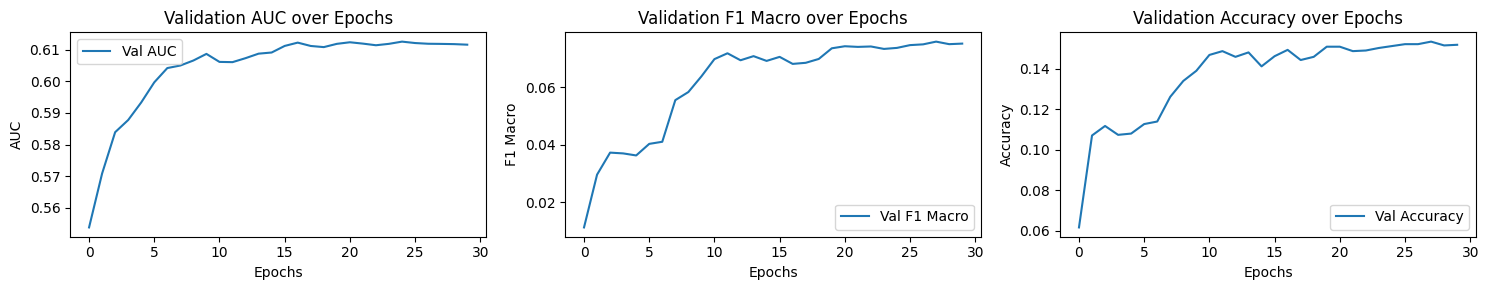

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15,3))

axs[0].plot(history['val_auc'], label='Val AUC')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('AUC')
axs[0].set_title('Validation AUC over Epochs')
axs[0].legend()

axs[1].plot(history['val_f1'], label='Val F1 Macro')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('F1 Macro')
axs[1].set_title('Validation F1 Macro over Epochs')
axs[1].legend()

axs[2].plot(history['val_acc'], label='Val Accuracy')
axs[2].set_xlabel('Epochs')
axs[2].set_ylabel('Accuracy')
axs[2].set_title('Validation Accuracy over Epochs')
axs[2].legend()

plt.tight_layout()
plt.show()

Batch shape: xb=torch.Size([1024, 1, 512]), yb=torch.Size([1024])
Accuracy on this batch: 0.1396


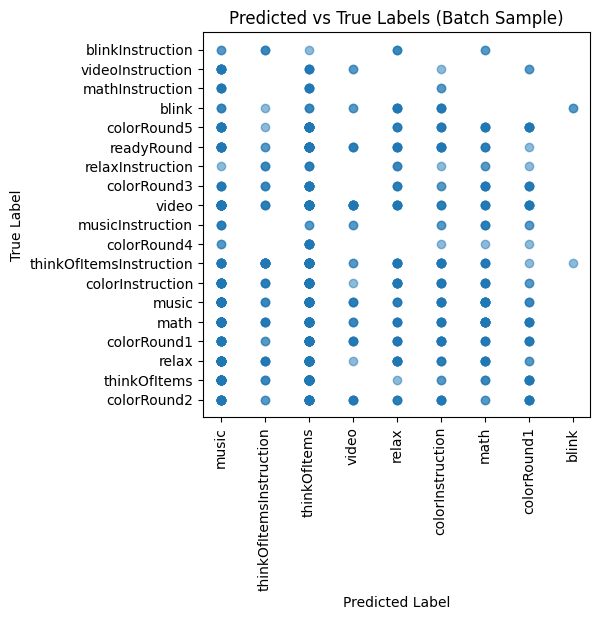

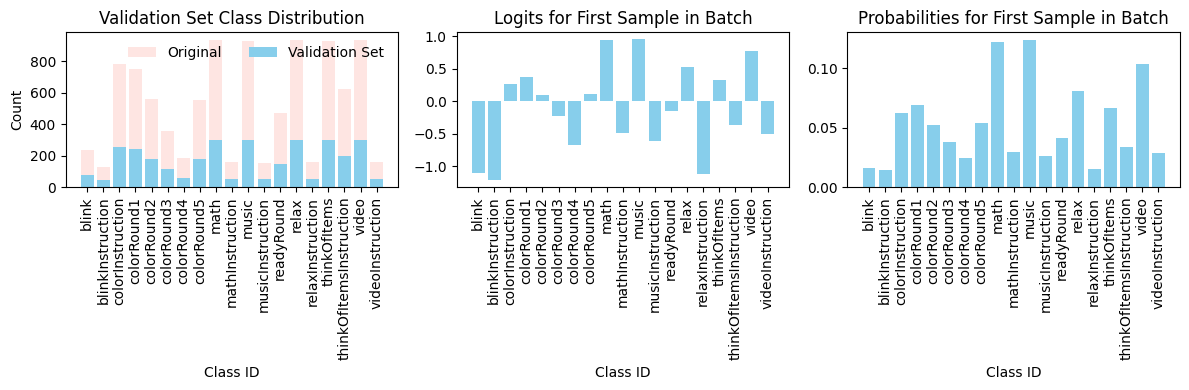

In [19]:
# one batch
xb, yb = next(iter(train_loader))
print(f"Batch shape: xb={xb.shape}, yb={yb.shape}")
# print(f"Label values in batch: {yb.unique().tolist()}")
# print(f"Label encoder classes: {label_encoder.classes_}")
# print(f"Num classes: {num_classes}")

# only going through forward pass
xb = xb.to(DEVICE)
yb = yb.to(DEVICE)
with torch.no_grad():
    logits = model(xb)
    probs = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1)

# print(f"\nLogits shape: {logits.shape}")
# print(f"Logits sample: {logits[0]}")
# print(f"Probs sample: {probs[0]}")
# print(f"Predictions sample: {preds[:10]}")
# print(f"True labels sample: {yb[:10]}")
print(f"Accuracy on this batch: {(preds == yb).float().mean():.4f}")

predicted_labels = label_encoder.inverse_transform(preds.cpu().numpy())
true_labels = label_encoder.inverse_transform(yb.cpu().numpy())

plt.figure(figsize=(5, 5))
plt.scatter(predicted_labels, true_labels, alpha=0.5)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Predicted vs True Labels (Batch Sample)')
plt.xticks(rotation=90)
plt.show()

val_labels = []
for xb, yb in val_loader:
    val_labels.extend(yb.tolist())
val_labels = np.array(val_labels)
unique, counts = np.unique(val_labels, return_counts=True)
# for u, c in zip(unique, counts):
#     print(f"  Class {u}: {c} samples")

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].bar(label_encoder.classes_, eeg_data.label.value_counts().reindex(label_encoder.classes_), color='salmon', alpha=0.2, label='Original')
axs[0].bar(label_encoder.classes_, counts, color='skyblue', label='Validation Set')
axs[0].set_title('Validation Set Class Distribution')
axs[0].set_xlabel('Class ID')
axs[0].set_ylabel('Count')
axs[0].tick_params(axis='x', rotation=90)
axs[0].legend(
    ncol=2,
    loc='upper right',
    frameon=False,
    framealpha=0.85,
    edgecolor='black',
    facecolor='white',
    fancybox=False,
    borderpad=0.4,
    borderaxespad=0.6,
)

axs[1].bar(label_encoder.classes_, logits[0].cpu().numpy(), color='skyblue')
axs[1].set_title('Logits for First Sample in Batch')
axs[1].set_xlabel('Class ID')
axs[1].tick_params(axis='x', rotation=90)

axs[2].bar(label_encoder.classes_, probs[0].cpu().numpy(), color='skyblue')
axs[2].set_title('Probabilities for First Sample in Batch')
axs[2].set_xlabel('Class ID')
axs[2].tick_params(axis='x', rotation=90)

fig.tight_layout()
plt.show()


## Group-aware K-fold cross-validation

> This section runs subject-wise CV (`id` as group) so validation subjects are never seen in training.


In [20]:
if KFOLD_ENABLED:
    debug_size = DEBUG_SIZE if DEBUG else len(eeg_data)
    cv_data = eeg_data.iloc[:debug_size].copy().reset_index(drop=True)

    if 'id' not in cv_data.columns:
        raise RuntimeError("K-fold requires subject ids in column 'id'.")

    def evaluate_fold(model, dataloader, criterion, n_classes):
        eval_metrics = {}
        model.eval()
        total_loss = 0.0
        all_labels = []
        all_preds = []
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * inputs.size(0)

                all_labels.append(labels.cpu())
                all_preds.append(outputs.cpu())

        avg_loss = total_loss / max(1, len(dataloader.dataset))
        all_labels = torch.cat(all_labels)
        all_preds = torch.cat(all_preds)

        y_true = all_labels.numpy()
        y_logits = all_preds.numpy()
        y_pred = y_logits.argmax(axis=1)

        eval_metrics['accuracy'] = accuracy_score(y_true, y_pred)
        eval_metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro')

        def top_k_accuracy(y_true_, y_scores_, k=2):
            top_k_preds = np.argsort(y_scores_, axis=1)[:, -k:]
            return float(np.mean([y_true_[i] in top_k_preds[i] for i in range(len(y_true_))]))

        if n_classes >= 2:
            eval_metrics['top_2_accuracy'] = top_k_accuracy(y_true, y_logits, k=2)
        if n_classes >= 3:
            eval_metrics['top_3_accuracy'] = top_k_accuracy(y_true, y_logits, k=3)

        try:
            probs = torch.softmax(torch.tensor(y_logits), dim=1).numpy()
            eval_metrics['auc_macro_ovr'] = roc_auc_score(
                y_true,
                probs,
                multi_class='ovr',
                labels=range(n_classes),
                average='macro',
            )
        except ValueError:
            eval_metrics['auc_macro_ovr'] = float('nan')

        return eval_metrics, avg_loss

    groups = cv_data['id'].values
    y_all = cv_data['label'].astype(str).values

    try:
        from sklearn.model_selection import StratifiedGroupKFold
        splitter = StratifiedGroupKFold(n_splits=KFOLD_N_SPLITS, shuffle=True, random_state=42)
        split_iter = splitter.split(cv_data, y_all, groups=groups)
        split_name = 'StratifiedGroupKFold'
    except Exception:
        splitter = model_selection.GroupKFold(n_splits=KFOLD_N_SPLITS)
        split_iter = splitter.split(cv_data, y_all, groups=groups)
        split_name = 'GroupKFold (fallback)'

    print(f'CV splitter: {split_name}')
    print(f'Total samples: {len(cv_data)} | unique subjects: {cv_data["id"].nunique()}')

    fold_rows = []

    for fold_idx, (tr_idx, va_idx) in enumerate(split_iter, start=1):
        fold_train = cv_data.iloc[tr_idx].copy().reset_index(drop=True)
        fold_val = cv_data.iloc[va_idx].copy().reset_index(drop=True)

        label_encoder_fold = preprocessing.LabelEncoder().fit(fold_train['label'])
        fold_val = fold_val[fold_val['label'].isin(label_encoder_fold.classes_)].copy().reset_index(drop=True)

        if len(fold_val) == 0:
            print(f'Fold {fold_idx}: skipped (no encodable validation labels).')
            continue

        fold_train, fold_val = _fit_split_safe_scalers(fold_train, fold_val)

        train_ds_fold = EEGDataset(fold_train, label_encoder=label_encoder_fold, seq_len=SEQ_LEN)
        val_ds_fold = EEGDataset(fold_val, label_encoder=label_encoder_fold, seq_len=SEQ_LEN)

        loader_kwargs = {'batch_size': BATCH_SIZE, 'num_workers': 0}
        if DEVICE == 'cuda':
            loader_kwargs['pin_memory'] = True

        if USE_WEIGHTED_SAMPLER:
            train_label_ids = train_ds_fold.y.cpu().numpy()
            class_counts = np.bincount(train_label_ids, minlength=len(label_encoder_fold.classes_))
            class_counts[class_counts == 0] = 1
            sample_weights = 1.0 / class_counts[train_label_ids]
            sample_weights = torch.tensor(sample_weights, dtype=torch.double)
            train_sampler = WeightedRandomSampler(
                weights=sample_weights,
                num_samples=len(sample_weights),
                replacement=True,
            )
            train_loader_fold = DataLoader(train_ds_fold, sampler=train_sampler, **loader_kwargs)
        else:
            train_loader_fold = DataLoader(train_ds_fold, shuffle=True, **loader_kwargs)

        val_loader_fold = DataLoader(val_ds_fold, shuffle=False, **loader_kwargs)

        n_classes_fold = len(label_encoder_fold.classes_)
        train_class_props = fold_train['label'].value_counts(normalize=True).reindex(
            label_encoder_fold.classes_,
            fill_value=1e-8,
        )

        effective_use_class_weights = USE_CLASS_WEIGHTS and (not USE_WEIGHTED_SAMPLER)
        if effective_use_class_weights:
            weights = (1.0 - train_class_props).values.astype(np.float32)
        else:
            weights = np.ones(n_classes_fold, dtype=np.float32)

        class_weights_fold = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

        model_fold = EEG1DCNN(
            num_classes=n_classes_fold,
            in_channels=1,
            seq_len=SEQ_LEN,
            dropout=DROPOUT,
        ).to(DEVICE)
        init_weights(model_fold)

        criterion_fold = nn.CrossEntropyLoss(weight=class_weights_fold, label_smoothing=LABEL_SMOOTHING)
        optimizer_fold = optim.AdamW(model_fold.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler_fold = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer_fold,
            T_max=KFOLD_MAX_EPOCHS,
            eta_min=LR / 100,
        )

        best_val_f1 = -1.0
        best_state = None
        epochs_no_improve = 0

        for epoch in range(1, KFOLD_MAX_EPOCHS + 1):
            model_fold.train()
            running_loss = 0.0

            for xb, yb in train_loader_fold:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                optimizer_fold.zero_grad()
                logits = model_fold(xb)
                loss = criterion_fold(logits, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_fold.parameters(), MAX_GRAD_NORM)
                optimizer_fold.step()

                running_loss += loss.item() * xb.size(0)

            scheduler_fold.step()
            train_loss = running_loss / max(1, len(train_loader_fold.dataset))

            val_metrics, val_loss = evaluate_fold(
                model_fold,
                val_loader_fold,
                criterion_fold,
                n_classes_fold,
            )

            if val_metrics['f1_macro'] > best_val_f1:
                best_val_f1 = val_metrics['f1_macro']
                best_state = {k: v.detach().cpu().clone() for k, v in model_fold.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            print(
                f"Fold {fold_idx}/{KFOLD_N_SPLITS} | Epoch {epoch:02d}/{KFOLD_MAX_EPOCHS} "
                f"| train_loss={train_loss:.4f} | val_f1={val_metrics['f1_macro']:.4f} "
                f"| val_acc={val_metrics['accuracy']:.4f} | val_auc={val_metrics['auc_macro_ovr']:.4f}"
            )

            if epochs_no_improve >= EARLY_STOP_PATIENCE:
                print(f'Fold {fold_idx}: early stopping at epoch {epoch}.')
                break

        if best_state is not None:
            model_fold.load_state_dict(best_state)

        final_metrics, final_val_loss = evaluate_fold(
            model_fold,
            val_loader_fold,
            criterion_fold,
            n_classes_fold,
        )

        row = {
            'fold': fold_idx,
            'splitter': split_name,
            'train_samples': int(len(fold_train)),
            'val_samples': int(len(fold_val)),
            'train_subjects': int(fold_train['id'].nunique()),
            'val_subjects': int(fold_val['id'].nunique()),
            'num_classes': int(n_classes_fold),
            'val_loss': float(final_val_loss),
            'f1_macro': float(final_metrics['f1_macro']),
            'accuracy': float(final_metrics['accuracy']),
            'auc_macro_ovr': float(final_metrics['auc_macro_ovr']),
            'top_2_accuracy': float(final_metrics.get('top_2_accuracy', float('nan'))),
            'top_3_accuracy': float(final_metrics.get('top_3_accuracy', float('nan'))),
        }
        fold_rows.append(row)
        print(
            f"Fold {fold_idx} final -> f1_macro={row['f1_macro']:.4f}, "
            f"acc={row['accuracy']:.4f}, auc={row['auc_macro_ovr']:.4f}"
        )

    if len(fold_rows) == 0:
        raise RuntimeError('No valid folds were produced. Check class coverage and group split settings.')

    cv_results = pd.DataFrame(fold_rows).sort_values('fold').reset_index(drop=True)
    print('\nPer-fold metrics:')
    display(cv_results)

    summary = {
        'splitter': split_name,
        'n_folds_completed': int(len(cv_results)),
        'f1_macro_mean': float(cv_results['f1_macro'].mean()),
        'f1_macro_std': float(cv_results['f1_macro'].std(ddof=0)),
        'accuracy_mean': float(cv_results['accuracy'].mean()),
        'accuracy_std': float(cv_results['accuracy'].std(ddof=0)),
        'auc_macro_ovr_mean': float(np.nanmean(cv_results['auc_macro_ovr'].values)),
        'auc_macro_ovr_std': float(np.nanstd(cv_results['auc_macro_ovr'].values)),
        'top_2_accuracy_mean': float(np.nanmean(cv_results['top_2_accuracy'].values)),
        'top_3_accuracy_mean': float(np.nanmean(cv_results['top_3_accuracy'].values)),
    }

    print('\nCV summary:')
    for k, v in summary.items():
        if isinstance(v, float):
            print(f'  {k}: {v:.4f}')
        else:
            print(f'  {k}: {v}')

    cv_results_path = REPORT_DIR / 'training_monitor_group_kfold_results.csv'
    cv_summary_path = REPORT_DIR / 'training_monitor_group_kfold_summary.json'
    cv_results.to_csv(cv_results_path, index=False)
    cv_summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
    print(f'\nSaved per-fold results: {cv_results_path}')
    print(f'Saved summary: {cv_summary_path}')
else:
    print('KFOLD_ENABLED=False -> skipping K-fold section.')

CV splitter: StratifiedGroupKFold
Total samples: 9954 | unique subjects: 30
Fold 1/5 | Epoch 01/20 | train_loss=2.9400 | val_f1=0.0140 | val_acc=0.0566 | val_auc=0.5626
Fold 1/5 | Epoch 02/20 | train_loss=2.8722 | val_f1=0.0393 | val_acc=0.1060 | val_auc=0.5712
Fold 1/5 | Epoch 03/20 | train_loss=2.8300 | val_f1=0.0289 | val_acc=0.1065 | val_auc=0.5888
Fold 1/5 | Epoch 04/20 | train_loss=2.8153 | val_f1=0.0346 | val_acc=0.1086 | val_auc=0.5921
Fold 1/5 | Epoch 05/20 | train_loss=2.8030 | val_f1=0.0340 | val_acc=0.1091 | val_auc=0.5991
Fold 1/5 | Epoch 06/20 | train_loss=2.7926 | val_f1=0.0423 | val_acc=0.1210 | val_auc=0.6093
Fold 1/5 | Epoch 07/20 | train_loss=2.7894 | val_f1=0.0482 | val_acc=0.1236 | val_auc=0.6156
Fold 1/5 | Epoch 08/20 | train_loss=2.7821 | val_f1=0.0527 | val_acc=0.1226 | val_auc=0.6194
Fold 1/5 | Epoch 09/20 | train_loss=2.7753 | val_f1=0.0676 | val_acc=0.1512 | val_auc=0.6239
Fold 1/5 | Epoch 10/20 | train_loss=2.7756 | val_f1=0.0663 | val_acc=0.1481 | val_auc=0

,fold,splitter,train_samples,val_samples,train_subjects,val_subjects,num_classes,val_loss,f1_macro,accuracy,auc_macro_ovr,top_2_accuracy,top_3_accuracy
0,1,StratifiedGroupKFold,8029,1925,25,5,19,2.740282,0.067586,0.151169,0.623873,0.256623,0.337662
1,2,StratifiedGroupKFold,7718,2236,23,7,19,2.776577,0.053911,0.120751,0.561124,0.246422,0.330054
2,3,StratifiedGroupKFold,8035,1919,24,6,19,2.750327,0.053370,0.122981,0.601398,0.253778,0.350182
3,4,StratifiedGroupKFold,8027,1927,24,6,19,2.801518,0.042952,0.102231,0.564544,0.221069,0.310327
4,5,StratifiedGroupKFold,8007,1947,24,6,19,2.795389,0.057114,0.112994,0.553034,0.221366,0.308680



CV summary:
  splitter: StratifiedGroupKFold
  n_folds_completed: 5
  f1_macro_mean: 0.0550
  f1_macro_std: 0.0079
  accuracy_mean: 0.1220
  accuracy_std: 0.0163
  auc_macro_ovr_mean: 0.5808
  auc_macro_ovr_std: 0.0272
  top_2_accuracy_mean: 0.2399
  top_3_accuracy_mean: 0.3274

Saved per-fold results: outputs\reports\training_monitor_group_kfold_results.csv
Saved summary: outputs\reports\training_monitor_group_kfold_summary.json
